# EDA para la generación de hipótesis — Telco Customer Churn

**Pregunta problema:** ¿Es posible predecir, a partir de la información de un cliente de telecomunicaciones (datos demográficos, contrato, servicios contratados y cargos), si este cancelará sus servicios (Churn) o continuará con ellos (No Churn), mediante un modelo de clasificación automática binaria?

**Objetivo de este notebook:** hacer el entendimiento y la exploración de los datos (Etapa 1, siguiendo la misma estructura del notebook guía del curso) para tener evidencia numérica concreta que respalde cada una de las 4 hipótesis que vamos a proponer en el debate "Hipótesis para revisión". Según la rúbrica del curso, cada hipótesis debe: describir una manera de solucionar el problema, mencionar requerimientos sobre los datos, definir claramente la técnica, y ser coherente. Este EDA alimenta directamente los tres primeros criterios.

**Nota:** ejecuta las celdas en orden (Entorno de ejecución → Ejecutar todas, en Colab).

In [1]:
# Carga de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
# Carga de datos
# Mismo dataset de Kaggle "Telco Customer Churn" (blastchar), replicado por IBM en este mirror público
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
data = pd.read_csv(url)
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Etapa 1: Entendimiento de los datos

Antes de preprocesar, debemos conocer las características del conjunto de datos:
- ¿Cuántos registros hay? ¿Cuántos atributos tiene cada registro? ¿De qué tipo son?
- Medidas de centralidad y dispersión de los atributos.
- Matriz de correlación para identificar atributos redundantes.
- Datos faltantes, datos atípicos y desbalance entre clases.

En esta etapa no se modifica ningún dato, solo se conocen a fondo.

In [3]:
# Número de registros y de atributos
data.shape

(7043, 21)

In [4]:
# Tipo de cada atributo
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [5]:
# customerID debe ser único (es el identificador del cliente, no aporta valor predictivo)
print("Registros:", len(data))
print("customerID únicos:", data['customerID'].nunique())

Registros: 7043
customerID únicos: 7043


In [6]:
# Medidas de centralidad y dispersión para los atributos numéricos
# Ojo: TotalCharges viene como texto en el CSV crudo, se corrige en la siguiente celda
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Corrección de tipo: TotalCharges debería ser numérico
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [8]:
# Medida de centralidad para atributos categóricos (moda)
data.select_dtypes(include='object').drop(columns=['customerID']).mode().iloc[0]

,0
gender,Male
Partner,No
Dependents,No
PhoneService,Yes
MultipleLines,No
InternetService,Fiber optic
OnlineSecurity,No
OnlineBackup,No
DeviceProtection,No
TechSupport,No


### Datos faltantes

`TotalCharges` quedó con valores nulos tras la conversión a numérico (venían como strings vacíos en el CSV original). Se revisa cuántos son y a qué clientes corresponden.

In [9]:
# Cuántos datos faltantes hay por cada atributo
data.isnull().sum()[data.isnull().sum() > 0]

,0
TotalCharges,11


In [10]:
# ¿A qué clientes corresponden los TotalCharges nulos?
data[data['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


Los 11 valores nulos corresponden exactamente a clientes con `tenure = 0`, es decir, clientes nuevos que aún no completan su primer ciclo de facturación. No es un dato faltante por error de captura, sino un caso estructural: TotalCharges = 0 tiene sentido para ellos. Esto es un requerimiento de datos importante a mencionar en las hipótesis (cómo se tratarán estos 11 registros).

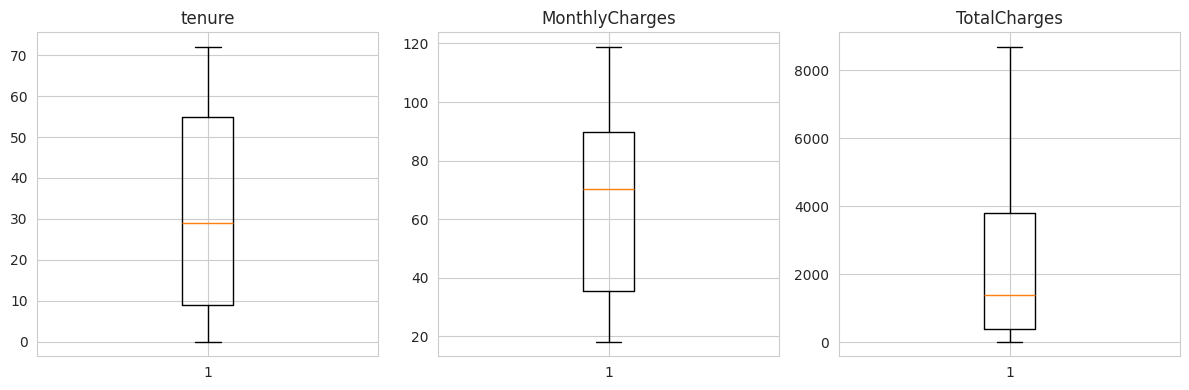

In [11]:
# Diagrama de cajas y bigotes para los atributos numéricos
# Permite identificar la existencia de datos atípicos
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    ax.boxplot(data[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

No se observan outliers extremos en las tres variables numéricas: sus rangos son consistentes con lo esperado (tenure entre 0 y 72 meses, cargos mensuales entre ~18 y ~120 USD).

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


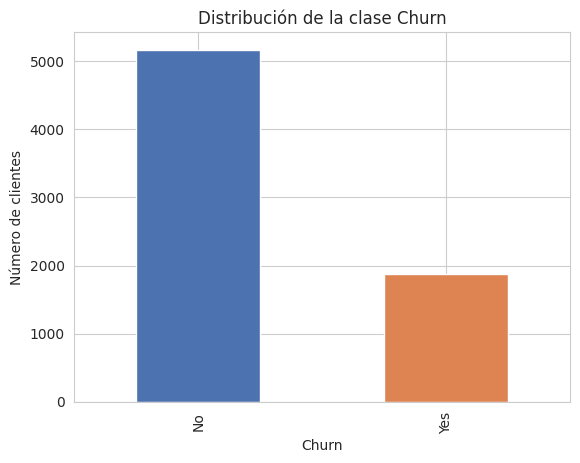

In [12]:
# Balance de clases del atributo de salida (Churn)
print(data['Churn'].value_counts())
print((data['Churn'].value_counts(normalize=True) * 100).round(1))

data['Churn'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Distribución de la clase Churn')
plt.ylabel('Número de clientes')
plt.show()

**Desbalance de clases confirmado:** 73.5% No Churn vs 26.5% Churn. Esto es un requerimiento que toda hipótesis debe mencionar (necesidad de recall/F1/ROC-AUC además de accuracy, y posible uso de SMOTE, ponderación de clases o similar).

## Correlación y colinealidad entre atributos numéricos

Los compañeros de varios grupos (G1, GX) señalan que `TotalCharges ≈ tenure × MonthlyCharges`. Se verifica con la matriz de correlación.

                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


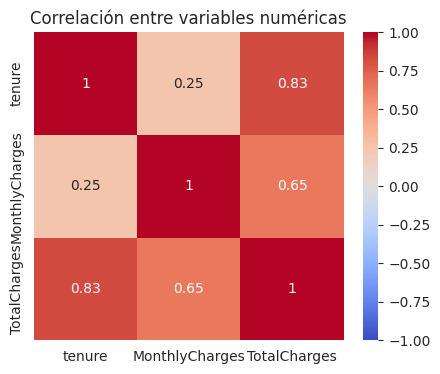

In [13]:
corr = data[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
print(corr.round(3))

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre variables numéricas')
plt.show()

`TotalCharges` está muy correlacionado con `tenure` (0.83) y con `MonthlyCharges` (0.65), confirmando la relación aproximada que señalaron los compañeros. Es un punto a considerar en técnicas sensibles a colinealidad (regresión logística, SVM lineal): descartar `TotalCharges` o aplicar regularización/reducción de dimensionalidad.

## Análisis bivariado: variables vs. Churn

Esta sección busca evidencia concreta (números, no solo intuición) para justificar la elección de técnica y los requerimientos de cada hipótesis.

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       37.6            61.3        2555.3
Yes      18.0            74.4        1531.8


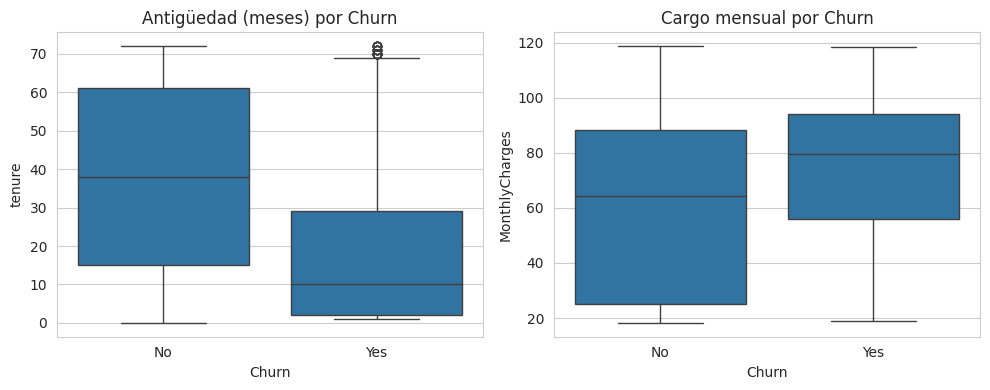

In [14]:
# Tenure y MonthlyCharges promedio por clase
resumen = data.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(1)
print(resumen)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=data, x='Churn', y='tenure', ax=axes[0])
axes[0].set_title('Antigüedad (meses) por Churn')
sns.boxplot(data=data, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Cargo mensual por Churn')
plt.tight_layout()
plt.show()

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


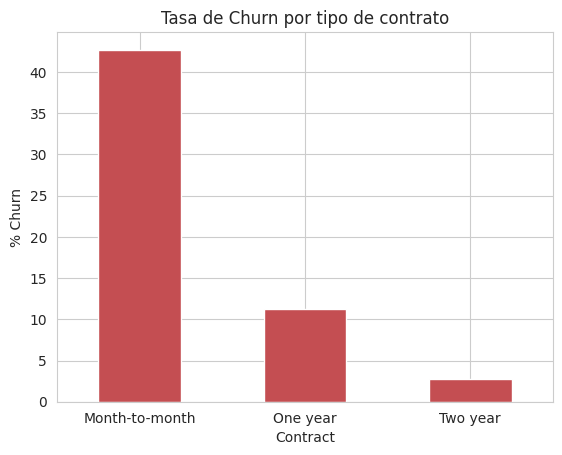

In [15]:
# % de Churn por tipo de contrato
churn_contract = (data.groupby('Contract')['Churn']
                   .apply(lambda s: (s == 'Yes').mean() * 100)
                   .round(1)
                   .sort_values(ascending=False))
print(churn_contract)

churn_contract.plot(kind='bar', color='#C44E52')
plt.ylabel('% Churn')
plt.title('Tasa de Churn por tipo de contrato')
plt.xticks(rotation=0)
plt.show()

PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn, dtype: float64


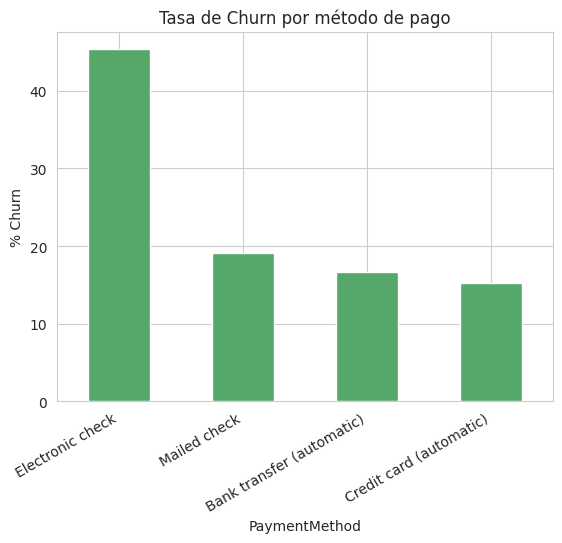

In [16]:
# % de Churn por método de pago
churn_payment = (data.groupby('PaymentMethod')['Churn']
                  .apply(lambda s: (s == 'Yes').mean() * 100)
                  .round(1)
                  .sort_values(ascending=False))
print(churn_payment)

churn_payment.plot(kind='bar', color='#55A868')
plt.ylabel('% Churn')
plt.title('Tasa de Churn por método de pago')
plt.xticks(rotation=30, ha='right')
plt.show()

In [17]:
# % de Churn por tipo de servicio de internet y por ausencia de servicios adicionales
servicios = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
             'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in servicios:
    print(f"\n--- {col} ---")
    print((data.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).round(1)))


--- InternetService ---
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     41.8
No internet service     7.4
Yes                    14.6
Name: Churn, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     39.9
No internet service     7.4
Yes                    21.5
Name: Churn, dtype: float64

--- DeviceProtection ---
DeviceProtection
No                     39.1
No internet service     7.4
Yes                    22.5
Name: Churn, dtype: float64

--- TechSupport ---
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2
Name: Churn, dtype: float64

--- StreamingTV ---
StreamingTV
No                     33.5
No internet service     7.4
Yes                    30.1
Name: Churn, dtype: float64

--- StreamingMovies ---
StreamingMovies
No                     33.7
No internet service     7.4
Yes                    29.9
Nam

### Niveles redundantes en variables de servicios

Varias variables de servicios (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) incluyen la categoría "No internet service", que es redundante con `InternetService = No`. Se verifica que coincidan exactamente los mismos clientes.

In [18]:
# Verificación de redundancia
mask_no_internet = data['InternetService'] == 'No'
for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    coincide = (data.loc[mask_no_internet, col] == 'No internet service').all()
    print(f"{col}: coincide 100% con InternetService=No -> {coincide}")

mask_no_phone = data['PhoneService'] == 'No'
coincide_lineas = (data.loc[mask_no_phone, 'MultipleLines'] == 'No phone service').all()
print(f"MultipleLines: coincide 100% con PhoneService=No -> {coincide_lineas}")

OnlineSecurity: coincide 100% con InternetService=No -> True
OnlineBackup: coincide 100% con InternetService=No -> True
DeviceProtection: coincide 100% con InternetService=No -> True
TechSupport: coincide 100% con InternetService=No -> True
StreamingTV: coincide 100% con InternetService=No -> True
StreamingMovies: coincide 100% con InternetService=No -> True
MultipleLines: coincide 100% con PhoneService=No -> True


Se confirma la redundancia total: ambas categorías pueden colapsarse a "No" sin pérdida de información, reduciendo la dimensionalidad tras la codificación one-hot (como ya anticipaban los compañeros de GX en su Hipótesis 1).

## Conclusiones del EDA — insumos para las 4 hipótesis

**1. Naturaleza mixta de los datos.** Hay 3 atributos numéricos continuos (tenure, MonthlyCharges, TotalCharges) y 16 categóricos. Cualquier hipótesis con técnicas sensibles a la escala (SVM, KNN, MLP) debe mencionar estandarización; cualquiera con técnicas de árboles no lo requiere.

**2. Desbalance de clases (73.5% / 26.5%).** Toda hipótesis debe mencionar cómo se abordará: ponderación de clases, SMOTE/SMOTE-NC, o ajuste del umbral de decisión, y qué métrica se priorizará (recall/F1/ROC-AUC, no solo accuracy).

**3. Colinealidad entre variables numéricas.** TotalCharges correlaciona 0.83 con tenure y 0.65 con MonthlyCharges. Técnicas lineales (regresión logística, SVM lineal) deberían justificar si descartan una variable o aplican regularización.

**4. Redundancia categórica confirmada.** "No internet service" y "No phone service" son 100% redundantes con InternetService/PhoneService — se pueden colapsar antes de codificar.

**5. Señales fuertes de churn (evidencia numérica, ya verificada contra los datos reales):**
- Antigüedad: clientes que cancelan tienen en promedio 18.0 meses vs. 37.6 de los que permanecen.
- Cargo mensual: 74.4 USD (Churn) vs. 61.3 USD (No Churn).
- Tipo de contrato: 42.7% de churn en Month-to-month vs. 11.3% en One year y solo 2.8% en Two year — la variable con mayor poder discriminante observado.
- Método de pago: 45.3% de churn con Electronic check, frente a 15-19% en los demás métodos.
- Servicios de valor agregado (OnlineSecurity, TechSupport, etc.): los clientes sin estos servicios muestran tasas de churn notablemente más altas que quienes sí los tienen.

**6. Faltantes estructurales, no aleatorios.** Los 11 nulos de TotalCharges corresponden a clientes con tenure=0; se pueden imputar como 0 sin riesgo de introducir sesgo.

Con esta evidencia numérica (ya no solo intuición) se pueden redactar hipótesis más específicas y defendibles ante la retroalimentación del profesor, quien en rondas anteriores ha pedido justificar los umbrales de desempeño y ser más específicos en los detalles de implementación (p. ej. cómo se convierten las variables categóricas).